Transformer 로 String 을 예측하는 문제를 해결하자
Depth 와 Organ type은 Special Token 으로 준비한다. d0, d1, d2, d4, o0, o1, o2, o4
SOS, PAD, EOS 도 마찬가지
파라미터는 KMeans로 클러스터링 해서 준비한다. 1d

In [1]:
import os
import numpy as np
from tqdm import tqdm
from string_to_xml_to_vec import xml2vec, pretty_print_xml, linked_to_recursive
import xml.etree.ElementTree as ET
plant_vectors = []
#dataset_dir = "../data/generated_Nov22_2024/xml"
dataset_dir = "../data/Sideview_Dec04_2024/xml"

# List xml files
xml_files = [f for f in os.listdir(dataset_dir) if f.endswith('.xml')]
xml_files.sort()
plant_array = []
for xml_file in tqdm(xml_files):
    xml_file = os.path.join(dataset_dir, xml_file)
    tree = ET.parse(xml_file)
    root = tree.getroot()
    root = linked_to_recursive(root)
    for plant_instance in root:
        plant_instance_array = []
        xml2vec(plant_instance, plant_instance_array)
        plant_array.append(plant_instance_array)

100%|██████████| 300/300 [00:05<00:00, 59.96it/s]


In [2]:
# Get the max depth and max len
max_depth = 0
max_len = 0
for plant_instance_array in plant_array:
    max_len = max(max_len, len(plant_instance_array))
    for plant in plant_instance_array:
        max_depth = max(max_depth, plant[0])

print("Max depth: ", max_depth)
print("Max len: ", max_len)

Max depth:  2
Max len:  358


In [3]:
from plant_tokenizer import unscale_vec, scale_vec
# The parameter will be quantized by organ types
all_shoot_params = []
all_internode_params = []
all_petiole_params = []
all_leaf_params = []
all_params_numbers = []
for plant_vectors in plant_array:
    # plant_vectors = scale_vec(plant_vectors)
    for vec in plant_vectors:
        depth = vec[0]
        organ_type = vec[1]
        if organ_type == 0:
            all_shoot_params.append(vec[2:])
        elif organ_type == 1:
            all_internode_params.append(vec[2:])
        elif organ_type == 2:
            all_petiole_params.append(vec[2:])
        elif organ_type == 3:
            all_leaf_params.append(vec[2:])
        all_params_numbers+= vec[2:]

all_shoot_params = np.array(all_shoot_params)
all_internode_params = np.array(all_internode_params)
all_petiole_params = np.array(all_petiole_params)
all_leaf_params = np.array(all_leaf_params)

print(all_shoot_params.shape)
print(all_internode_params.shape)
print(all_petiole_params.shape)
print(all_leaf_params.shape)
len(all_params_numbers)

(1316, 5)
(8795, 4)
(9095, 5)
(26085, 4)


191575

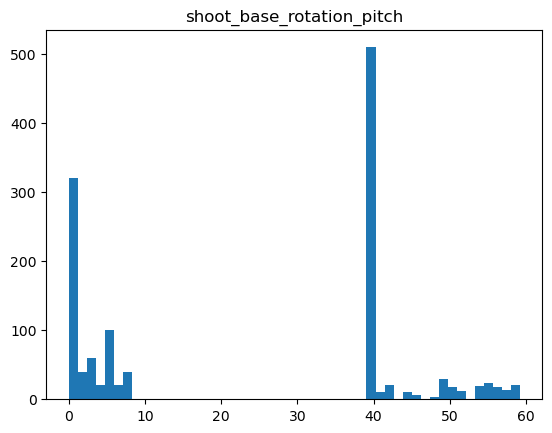

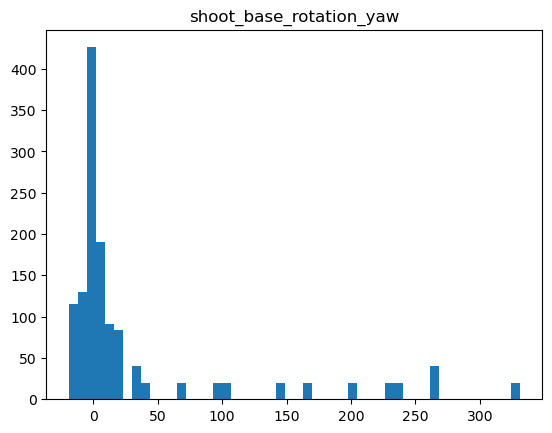

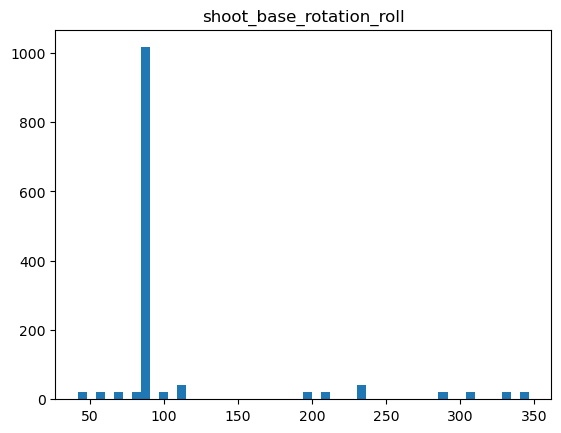

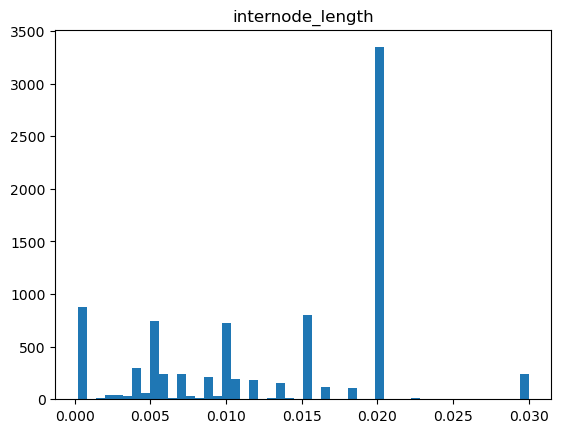

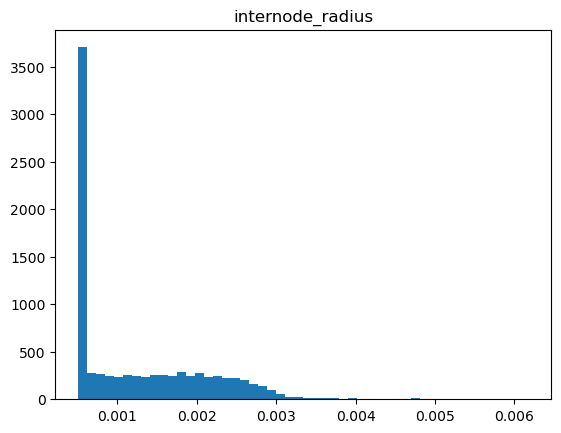

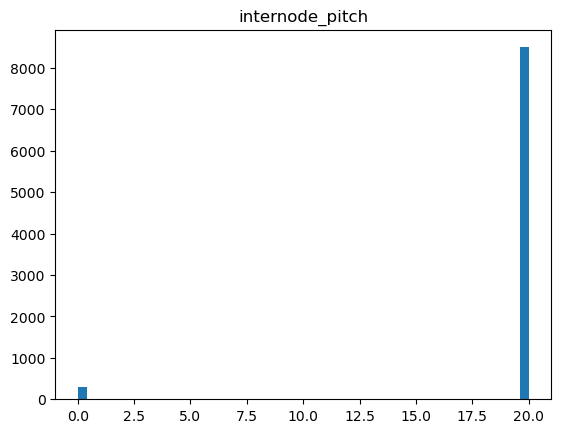

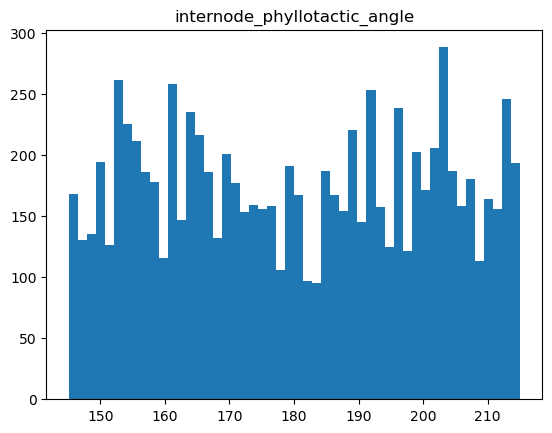

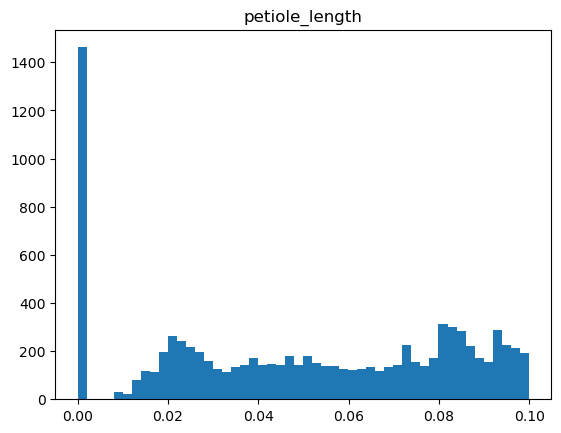

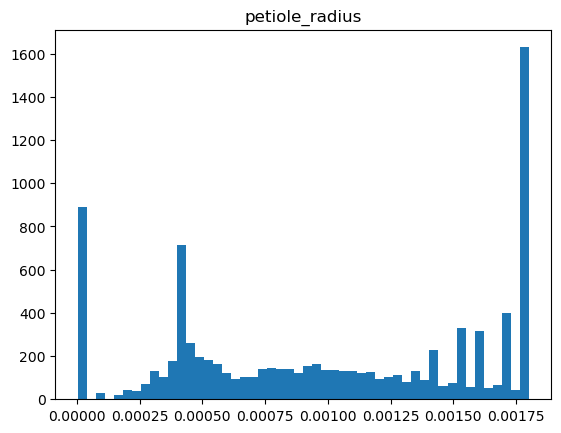

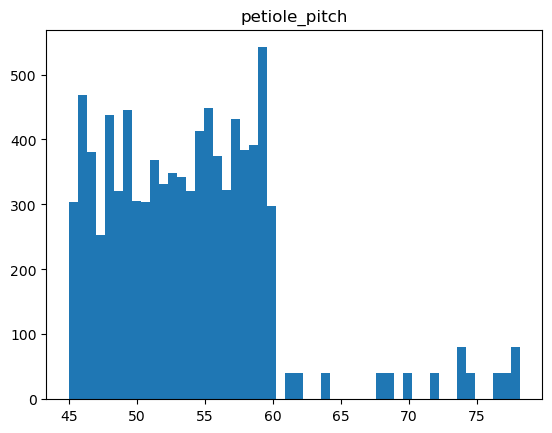

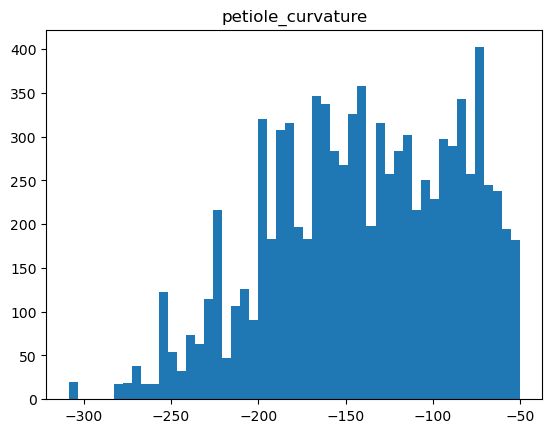

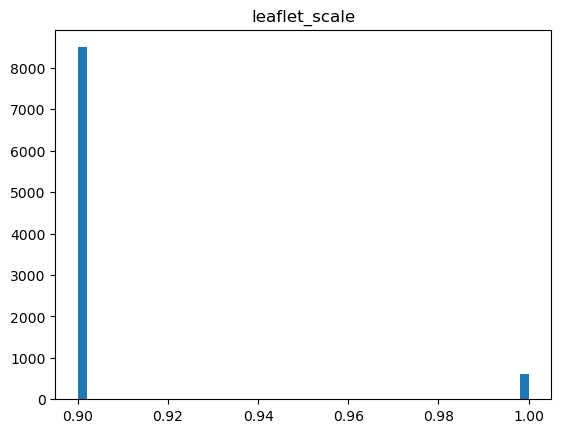

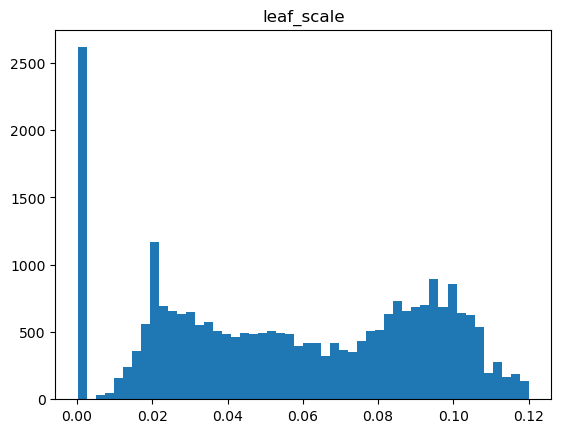

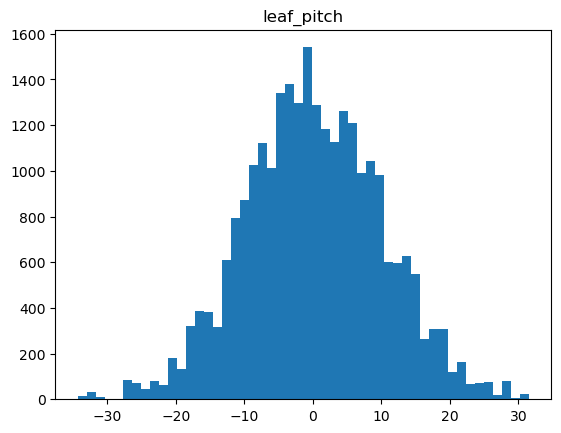

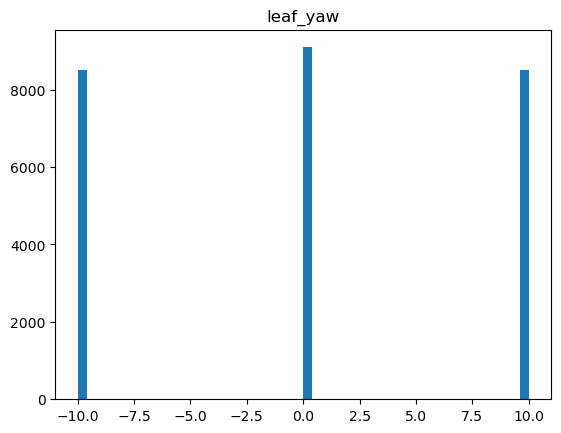

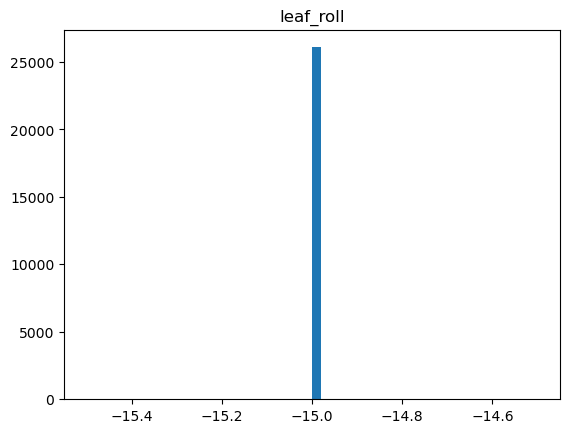

In [4]:
shoot_base_rotation_pitch = all_shoot_params[:, 0]
shoot_base_rotation_yaw = all_shoot_params[:, 1]
shoot_base_rotation_roll = all_shoot_params[:, 2]

internode_length = all_internode_params[:, 0]
internode_radius = all_internode_params[:, 1]
internode_pitch = all_internode_params[:, 2]
internode_phyllotactic_angle = all_internode_params[:, 3]

petiole_length = all_petiole_params[:, 0]
petiole_radius = all_petiole_params[:, 1]
petiole_pitch = all_petiole_params[:, 2]
petiole_curvature = all_petiole_params[:, 3]
leaflet_scale = all_petiole_params[:, 4]

leaf_scale = all_leaf_params[:, 0]
leaf_pitch = all_leaf_params[:, 1]
leaf_yaw = all_leaf_params[:, 2]
leaf_roll = all_leaf_params[:, 3]

# Visualize the distribution of the parameters
import matplotlib.pyplot as plt
plt.hist(shoot_base_rotation_pitch, bins=50)
plt.title("shoot_base_rotation_pitch")
plt.show()

plt.hist(shoot_base_rotation_yaw, bins=50)
plt.title("shoot_base_rotation_yaw")
plt.show()

plt.hist(shoot_base_rotation_roll, bins=50)
plt.title("shoot_base_rotation_roll")
plt.show()

plt.hist(internode_length, bins=50)
plt.title("internode_length")
plt.show()

plt.hist(internode_radius, bins=50)
plt.title("internode_radius")
plt.show()

plt.hist(internode_pitch, bins=50)
plt.title("internode_pitch")
plt.show()

plt.hist(internode_phyllotactic_angle, bins=50)
plt.title("internode_phyllotactic_angle")
plt.show()

plt.hist(petiole_length, bins=50)
plt.title("petiole_length")
plt.show()

plt.hist(petiole_radius, bins=50)
plt.title("petiole_radius")
plt.show()

plt.hist(petiole_pitch, bins=50)
plt.title("petiole_pitch")
plt.show()

plt.hist(petiole_curvature, bins=50)
plt.title("petiole_curvature")
plt.show()

plt.hist(leaflet_scale, bins=50)
plt.title("leaflet_scale")
plt.show()

plt.hist(leaf_scale, bins=50)
plt.title("leaf_scale")
plt.show()

plt.hist(leaf_pitch, bins=50)
plt.title("leaf_pitch")
plt.show()

plt.hist(leaf_yaw, bins=50)
plt.title("leaf_yaw")
plt.show()

plt.hist(leaf_roll, bins=50)
plt.title("leaf_roll")
plt.show()


In [5]:
import os
import numpy as np
import pickle
# Quantize the parameters
from sklearn.cluster import MiniBatchKMeans, KMeans


unique_params = np.unique(all_params_numbers)

# Create folder
if not os.path.exists('quantized_params'):
    os.makedirs('quantized_params')

if 0:
    all_params_numbers_array = np.unique(all_params_numbers)
    all_params_numbers_array = np.array(all_params_numbers_array).reshape(-1, 1)
    kmeans = MiniBatchKMeans(n_clusters=1000, random_state=0, batch_size=1024).fit(all_params_numbers_array)

    # Append frequently used parameters
    kmeans.cluster_centers_ = np.append(kmeans.cluster_centers_, np.array([0,1,3]).reshape(-1,1), axis=0)
else:
    # Make a custom kmeans
    predetermined_centers = np.concatenate([
                                            np.linspace(-360, 360, 18+1), # angles
                                            np.array([0, 10, -10, 15, -15, 20, 40, 90]), # Some special angles
                                            np.array([0.9, 1.0]), # Some special float values
                                            np.array([0, 1, 3]), # integer values
                                            np.linspace(0, 1.0, 11),
                                            np.linspace(0, 0.1, 11),
                                            np.linspace(0, 0.01, 11), # float values for lenghts
                                            np.linspace(0, 0.001, 11), # float values for lenghts
                                            ])
    predetermined_centers = np.unique(predetermined_centers).reshape(-1, 1)

    n_clusters = predetermined_centers.shape[0]
    print("n_clusters: ", n_clusters)
    kmeans = KMeans(n_clusters=n_clusters, init=predetermined_centers, n_init=1, max_iter=1)
    kmeans.fit(unique_params.reshape(-1, 1))

    kmeans.cluster_centers_ = predetermined_centers

with open('quantized_params/params_quantized_test.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
# Write the kmeans to txt using numpy
np.savetxt('quantized_params/params_quantized_test.txt', kmeans.cluster_centers_)


n_clusters:  63


In [6]:
# Calculate the quantized params
quantized_shoot_params = kmeans.predict(all_shoot_params.reshape(-1, 1))
quantized_internode_params = kmeans.predict(all_internode_params.reshape(-1, 1))
quantized_petiole_params = kmeans.predict(all_petiole_params.reshape(-1, 1))
quantized_leaf_params = kmeans.predict(all_leaf_params.reshape(-1, 1))

# Convert back to original params
original_shoot_params = kmeans.cluster_centers_[quantized_shoot_params].reshape(all_shoot_params.shape)
original_internode_params = kmeans.cluster_centers_[quantized_internode_params].reshape(all_internode_params.shape)
original_petiole_params = kmeans.cluster_centers_[quantized_petiole_params].reshape(all_petiole_params.shape)
original_leaf_params = kmeans.cluster_centers_[quantized_leaf_params].reshape(all_leaf_params.shape)

# Calculate the error
error_shoot = np.mean(np.abs(all_shoot_params - original_shoot_params))
error_internode = np.mean(np.abs(all_internode_params - original_internode_params))
error_petiole = np.mean(np.abs(all_petiole_params - original_petiole_params))
error_leaf = np.mean(np.abs(all_leaf_params - original_leaf_params))

print("Error shoot: ", error_shoot)
print("Error internode: ", error_internode)
print("Error petiole: ", error_petiole)
print("Error leaf: ", error_leaf)

Error shoot:  1.3764723123100302
Error internode:  2.1231429716365264
Error petiole:  4.531526828798725
Error leaf:  0.48769652594977003


In [7]:
# Get error distribution
error_shoot_distribution = np.abs(all_shoot_params - original_shoot_params)
error_internode_distribution = np.abs(all_internode_params - original_internode_params)
error_petiole_distribution = np.abs(all_petiole_params - original_petiole_params)
error_leaf_distribution = np.abs(all_leaf_params - original_leaf_params)

# Get the top 5 error samples
top5_shoot = np.argsort(error_shoot_distribution, axis=0)[-5:]
top5_internode = np.argsort(error_internode_distribution, axis=0)[-5:]  
top5_petiole = np.argsort(error_petiole_distribution, axis=0)[-5:]
top5_leaf = np.argsort(error_leaf_distribution, axis=0)[-5:]



In [8]:
# Print the top 5 error samples
print("Top 5 shoot error samples")
for i in range(5):
    print("Sample ", i)
    print("Original: ", all_shoot_params[top5_shoot[i]][0])
    print("Quantized: ", original_shoot_params[top5_shoot[i]][0])
    print("Error: ", error_shoot_distribution[top5_shoot[i]][0])
    print("")
    

Top 5 shoot error samples
Sample  0
Original:  [59.1945   5.48452 90.       0.       3.     ]
Quantized:  [40.  3. 90.  0.  3.]
Error:  [19.1945   2.48452  0.       0.       0.     ]

Sample  1
Original:  [59.1945   5.48452 90.       0.       3.     ]
Quantized:  [40.  3. 90.  0.  3.]
Error:  [19.1945   2.48452  0.       0.       0.     ]

Sample  2
Original:  [59.1945   5.48452 90.       0.       3.     ]
Quantized:  [40.  3. 90.  0.  3.]
Error:  [19.1945   2.48452  0.       0.       0.     ]

Sample  3
Original:  [59.1945   5.48452 90.       0.       3.     ]
Quantized:  [40.  3. 90.  0.  3.]
Error:  [19.1945   2.48452  0.       0.       0.     ]

Sample  4
Original:  [59.1945   5.48452 90.       0.       3.     ]
Quantized:  [40.  3. 90.  0.  3.]
Error:  [19.1945   2.48452  0.       0.       0.     ]



In [9]:
print("Top 5 petiole error samples")
for i in range(5):
    print("Sample ", i)
    print("Original: ", all_petiole_params[top5_petiole[i]][0])
    print("Quantized: ", original_petiole_params[top5_petiole[i]][0])
    print("Error: ", error_petiole_distribution[top5_petiole[i]][0])
    print("")

Top 5 petiole error samples
Sample  0
Original:  [ 1.49977e-02  2.85312e-04  4.66464e+01 -1.61272e+02  9.00000e-01]
Quantized:  [ 1.0e-02  3.0e-04  4.0e+01 -1.6e+02  9.0e-01]
Error:  [4.9977e-03 1.4688e-05 6.6464e+00 1.2720e+00 0.0000e+00]

Sample  1
Original:  [ 3.50022e-02  7.72686e-04  4.58470e+01 -2.00881e+02  9.00000e-01]
Quantized:  [ 4.e-02  8.e-04  4.e+01 -2.e+02  9.e-01]
Error:  [4.9978e-03 2.7314e-05 5.8470e+00 8.8100e-01 0.0000e+00]

Sample  2
Original:  [ 1.50012e-02  3.04666e-04  5.70079e+01 -2.69571e+02  9.00000e-01]
Quantized:  [ 2.0e-02  3.0e-04  4.0e+01 -2.8e+02  9.0e-01]
Error:  [4.99880e-03 4.66600e-06 1.70079e+01 1.04290e+01 0.00000e+00]

Sample  3
Original:  [ 1.49994e-02  3.05736e-04  4.90398e+01 -1.83699e+02  9.00000e-01]
Quantized:  [ 1.e-02  3.e-04  4.e+01 -2.e+02  9.e-01]
Error:  [4.9994e-03 5.7360e-06 9.0398e+00 1.6301e+01 0.0000e+00]

Sample  4
Original:  [ 1.49994e-02  3.05736e-04  4.90398e+01 -1.83699e+02  9.00000e-01]
Quantized:  [ 1.e-02  3.e-04  4.e+01 